In [5]:
import os
import pandas as pd
import gzip
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
import pysam
import pyranges as pr
from pandas.errors import EmptyDataError

In [9]:
print("Current working directory:", os.getcwd())

Current working directory: /home/pribus/ONTBC_analysis


In [8]:
os.chdir('..')

In [10]:
vcfs_path = "010825_ontbc_vcfs/"

In [11]:
all_l1s_raw = []

for file in os.listdir(vcfs_path):
    if file == ".ipynb_checkpoints":
        continue
        
    sample = file.split("tumor")[0]

    l1_file = os.path.join(vcfs_path, file)

    vcf_df = pd.read_csv(
        l1_file,
        compression='gzip',
        comment='#',
        sep='\t',
        header=None
    )

    vcf_df["sample"] = sample
    all_l1s_raw.append(vcf_df)

all_l1s_raw_df = pd.concat(all_l1s_raw, ignore_index=True)

new_column_names = ['chr', 'pos', 'id', 'red', 'alt', 'qual', 'filter', 'info', 'sample']
all_l1s_raw_df.columns = new_column_names

all_l1s_raw_df = all_l1s_raw_df[all_l1s_raw_df["filter"] == "PASS"]

In [12]:
def categorize_multi(row):
    info = str(row['info'])
    cats = []
    for cat in ['SVA','L1','Alu','SINE-R','VNTR','PSD','DUP']:
        if cat in info:
            cats.append(cat)
    if not cats:
        cats = ['Other']
    return cats

all_l1s_raw_df['categories'] = all_l1s_raw_df.apply(categorize_multi, axis=1)

df_expanded = all_l1s_raw_df.explode('categories')

In [13]:
final_mei_counts_tables = "013026_mei_checked/"

In [14]:
df_l1_filtered = df_expanded.copy()

for sample in df_expanded.loc[df_expanded["categories"] == "L1", "sample"].unique():

    l1_file = f"{final_mei_counts_tables}{sample}tumor.L1.table"

    try:
        l1_df = pd.read_csv(l1_file, sep="\t", header=None)

        # If file exists but has no rows
        if l1_df.empty:
            raise EmptyDataError

        valid_ids = set(l1_df[3])

    except (FileNotFoundError, EmptyDataError):
        # No valid IDs → drop all L1 rows for this sample
        df_l1_filtered = df_l1_filtered[
            ~((df_l1_filtered["sample"] == sample) &
              (df_l1_filtered["categories"] == "L1"))
        ]
        continue

    mask = (
        (df_l1_filtered["sample"] == sample) &
        (df_l1_filtered["categories"] == "L1") &
        (~df_l1_filtered["id"].isin(valid_ids))
    )

    df_l1_filtered = df_l1_filtered[~mask]

In [15]:
df_alu_filtered = df_l1_filtered.copy()

for sample in df_l1_filtered.loc[df_l1_filtered["categories"] == "Alu", "sample"].unique():

    alu_file = f"{final_mei_counts_tables}{sample}tumor.Alu.table"

    try:
        alu_df = pd.read_csv(alu_file, sep="\t", header=None)

        # If file exists but has no rows
        if alu_df.empty:
            raise EmptyDataError

        valid_ids = set(alu_df[3])

    except (FileNotFoundError, EmptyDataError):
        # No valid IDs → drop all L1 rows for this sample
        df_alu_filtered = df_alu_filtered[
            ~((df_alu_filtered["sample"] == sample) &
              (df_alu_filtered["categories"] == "Alu"))
        ]
        continue

    # Drop L1 rows whose IDs are NOT in the table
    mask = (
        (df_alu_filtered["sample"] == sample) &
        (df_alu_filtered["categories"] == "Alu") &
        (~df_alu_filtered["id"].isin(valid_ids))
    )

    df_alu_filtered = df_alu_filtered[~mask]

In [16]:
df_SVA_filtered = df_alu_filtered.copy()

for sample in df_alu_filtered.loc[df_alu_filtered["categories"] == "SVA", "sample"].unique():

    sva_file = f"{final_mei_counts_tables}{sample}tumor.SVA.table"

    try:
        sva_df = pd.read_csv(sva_file, sep="\t", header=None)

        # If file exists but has no rows
        if sva_df.empty:
            raise EmptyDataError

        valid_ids = set(sva_df[3])

    except (FileNotFoundError, EmptyDataError):
        # No valid IDs → drop all L1 rows for this sample
        df_SVA_filtered = df_SVA_filtered[
            ~((df_SVA_filtered["sample"] == sample) &
              (df_SVA_filtered["categories"] == "SVA"))
        ]
        continue

    # Drop L1 rows whose IDs are NOT in the table
    mask = (
        (df_SVA_filtered["sample"] == sample) &
        (df_SVA_filtered["categories"] == "SVA") &
        (~df_SVA_filtered["id"].isin(valid_ids))
    )

    df_SVA_filtered = df_SVA_filtered[~mask]

In [17]:
df_final_filtered = df_SVA_filtered.copy()

<Figure size 1200x600 with 0 Axes>

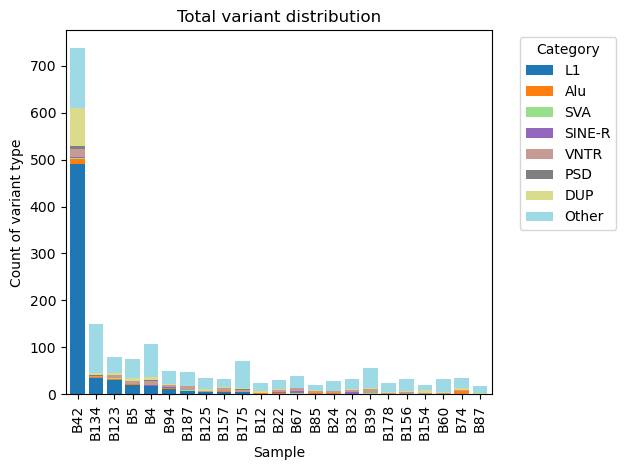

In [18]:
counts_df = df_final_filtered.groupby(['sample', 'categories']).size().unstack(fill_value=0)

category_order = ['L1','Alu','SVA', 'SINE-R','VNTR','PSD','DUP','Other']
counts_df = counts_df.reindex(columns=category_order, fill_value=0)

counts_df_sorted = counts_df.sort_values('L1', ascending=False)

plt.figure(figsize=(12,6))
counts_df_sorted.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.ylabel('Count of variant type')
plt.xlabel('Sample')
plt.title('Total variant distribution')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# --- Stacked proportion plot ---
prop_df_sorted = counts_df_sorted.div(counts_df_sorted.sum(axis=1), axis=0)
# Sort by L1 proportion descending
prop_df_sorted = prop_df_sorted.sort_values('L1', ascending=False)

plt.figure(figsize=(12,6))
prop_df_sorted.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.ylabel('Proportion of variant type')
plt.xlabel('Sample')
plt.title('Total variant distribution')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

In [52]:
all_l1s_df = df_final_filtered[df_final_filtered["categories"]=="L1"]

In [55]:
l1_bed = all_l1s_df[['chr','pos','id']].copy()
l1_bed.columns = ['Chromosome','Start','ID']
l1_bed['Start'] = l1_bed['Start'].astype(int)
l1_bed['End'] = l1_bed['Start'] + 1   # single base
l1_ranges = pr.PyRanges(l1_bed)

In [30]:
gtf_df = pd.read_csv("gencode.v38.annotation.txt", sep='\t', header=5)

In [31]:
gtf_file = "gencode.v38.annotation.txt"
gtf = pr.read_gtf(gtf_file)

In [32]:
exons = gtf[gtf.Feature == 'exon']
cds = gtf[gtf.Feature == 'CDS']
transcripts = gtf[gtf.Feature == 'transcript']

In [29]:
def infer_utr(transcript):
    strand = transcript.Strand.values[0]
    tx_start = transcript.Start.min()
    tx_end = transcript.End.max()
    transcript_id = transcript.transcript_id.values[0]
    transcript_cds = cds[cds.transcript_id == transcript_id]
    if len(transcript_cds) == 0:
        return None, None
    cds_start = transcript_cds.Start.min()
    cds_end = transcript_cds.End.max()
    if strand == '+':
        five_prime = pr.PyRanges(pd.DataFrame({
            'Chromosome':[transcript.Chromosome.values[0]],
            'Start':[tx_start],
            'End':[cds_start-1],
            'Strand':[strand],
            'Feature':['5UTR']
        }))
        three_prime = pr.PyRanges(pd.DataFrame({
            'Chromosome':[transcript.Chromosome.values[0]],
            'Start':[cds_end+1],
            'End':[tx_end],
            'Strand':[strand],
            'Feature':['3UTR']
        }))
    else:
        # reverse strand
        five_prime = pr.PyRanges(pd.DataFrame({
            'Chromosome':[transcript.Chromosome.values[0]],
            'Start':[cds_end+1],
            'End':[tx_end],
            'Strand':[strand],
            'Feature':['5UTR']
        }))
        three_prime = pr.PyRanges(pd.DataFrame({
            'Chromosome':[transcript.Chromosome.values[0]],
            'Start':[tx_start],
            'End':[cds_start-1],
            'Strand':[strand],
            'Feature':['3UTR']
        }))
    return five_prime, three_prime

In [33]:
utr_ranges = []
for _, tx in transcripts.df.groupby('transcript_id'):
    five, three = infer_utr(pr.PyRanges(tx))
    if five: utr_ranges.append(five)
    if three: utr_ranges.append(three)
utrs = pr.concat(utr_ranges)

KeyboardInterrupt: 

In [33]:
exons.df['Feature'] = 'exon'

introns = transcripts.subtract(exons)
introns.df['Feature'] = 'intron'

genes = transcripts

# Intergenic = genome - genes
# You can use CHR_LENGTHS dict for genome length
CHR_LENGTHS = {'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559, 'chr4': 190214555, 'chr5': 181538259,
               'chr6': 170805979, 'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717, 'chr10': 133797422,
               'chr11': 135086622, 'chr12': 133275309, 'chr13': 114364328, 'chr14': 107043717, 'chr15': 101991189,
               'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285, 'chr19': 58617616, 'chr20': 64444167,
               'chr21': 46709983, 'chr22': 50818468, 'chrX': 156040895}

all_chr_ranges = []
for chrom, length in CHR_LENGTHS.items():
    all_chr_ranges.append(pr.PyRanges(pd.DataFrame({
        'Chromosome':[chrom],
        'Start':[0],
        'End':[length],
        'Feature':['genome']
    })))
    
genome_ranges = pr.concat(all_chr_ranges)

intergenic = genome_ranges.subtract(genes)
intergenic.df['Feature'] = 'intergenic'

In [34]:
all_features = pr.concat([exons, introns, intergenic])

In [56]:
l1_ranges = pr.PyRanges(pd.DataFrame({
    'Chromosome': all_l1s_df['chr'],
    'Start': all_l1s_df['pos'],
    'End': all_l1s_df['pos']+1,
    'ID': all_l1s_df['id'],
    'Sample': all_l1s_df['sample']
}))

In [36]:
features = gtf[gtf.Feature.isin(['UTR','exon'])]

In [37]:
exons_pr = pr.PyRanges(exons.df[['Chromosome', 'Start', 'End', 'transcript_id']])
transcripts_pr = pr.PyRanges(transcripts.df[['Chromosome', 'Start', 'End', 'transcript_id']])
introns_pr = transcripts_pr.subtract(exons_pr)
introns_df = introns_pr.df.copy()
introns_df['Feature'] = 'intron'
introns_pr = pr.PyRanges(introns_df)

In [38]:
all_features = pd.concat([
    features.df[['Chromosome','Start','End','Feature']], 
    introns_pr.df[['Chromosome','Start','End','Feature']]
])
feature_ranges = pr.PyRanges(all_features)

In [39]:
all_features["Feature"].value_counts()

intron    1805569
exon      1499012
UTR        349402
Name: Feature, dtype: int64

In [57]:
overlaps = l1_ranges.join(feature_ranges, how='left')
overlaps_df = overlaps.df.copy()

In [58]:
overlaps_df['Feature'] = overlaps_df['Feature'].replace('-1', 'intergenic')

In [59]:
overlaps_df

,Chromosome,Start,End,ID,Sample,Start_b,End_b,Feature
0,chr1,197424911,197424912,INS00002510,B5,197422839,197427453,intron
1,chr1,197424911,197424912,INS00002510,B5,197422839,197427453,intron
2,chr1,197424911,197424912,INS00002510,B5,197422839,197427453,intron
3,chr1,197424911,197424912,INS00002510,B5,197422839,197427453,intron
4,chr1,197424911,197424912,INS00002510,B5,197422839,197427453,intron
...,...,...,...,...,...,...,...,...
2074,chrX,93770665,93770666,INS00039518,B42,-1,-1,intergenic
2075,chrX,95128817,95128818,INS00039524,B42,-1,-1,intergenic
2076,chrX,99803780,99803781,INS00039544,B42,-1,-1,intergenic
2077,chrX,108927315,108927316,INS00039591,B42,-1,-1,intergenic


In [60]:
l1_feature_df = overlaps_df.groupby('ID').first().reset_index()
l1_feature_df = l1_feature_df[['Sample','ID','Feature']]

In [61]:
l1_feature_df["Feature"].value_counts()

intron        326
intergenic    287
exon           20
Name: Feature, dtype: int64

In [62]:
annotated_l1s = all_l1s_df.merge(l1_feature_df, left_on=['sample', 'id'], right_on=['Sample', 'ID'], how='left')

<Figure size 1000x600 with 0 Axes>

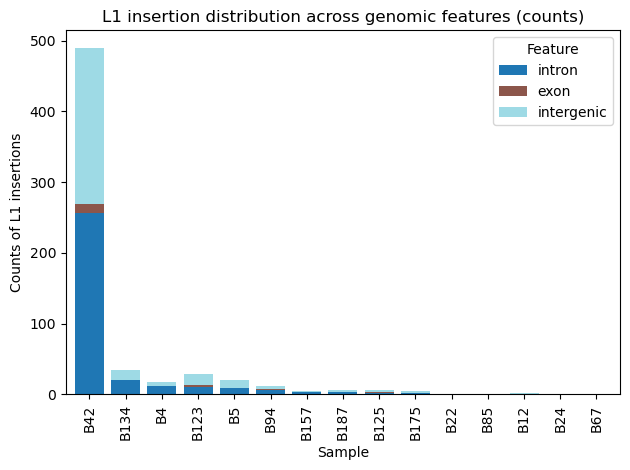

In [63]:
feature_order = ['intron', 'exon', 'intergenic']
annotated_l1s['Feature'] = pd.Categorical(annotated_l1s['Feature'], categories=feature_order, ordered=True)

counts_df = annotated_l1s.groupby(['sample','Feature']).size().unstack(fill_value=0)
counts_df_sorted = counts_df.sort_values(by='intron', ascending=False)

plt.figure(figsize=(10,6))
counts_df_sorted.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.ylabel('Counts of L1 insertions')
plt.xlabel('Sample')
plt.title('L1 insertion distribution across genomic features (counts)')
plt.xticks(rotation=90, ha='center')
plt.legend(title='Feature')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

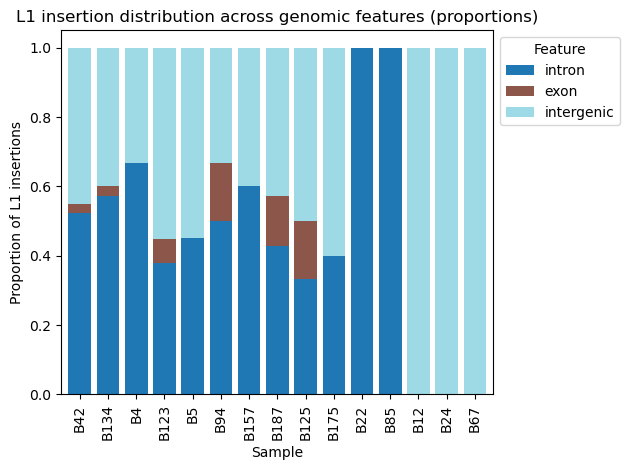

In [64]:
prop_df = counts_df_sorted.div(counts_df_sorted.sum(axis=1), axis=0)

plt.figure(figsize=(10,6))
prop_df.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.ylabel('Proportion of L1 insertions')
plt.xlabel('Sample')
plt.title('L1 insertion distribution across genomic features (proportions)')
plt.xticks(rotation=90, ha='center')
plt.legend(title='Feature', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()